In [9]:
import os
import re
import numpy as np
import pandas as pd
import json
from math import pow,factorial,log,exp
from matplotlib import pyplot as plt, colors

TEST_SERVICE = os.path.join('alternative')

notebook_folder = os.getcwd()
print(f"Current notebook folder: {notebook_folder}")

RESULT_FOLDER = os.path.join(notebook_folder, TEST_SERVICE)

TEST_PATH = os.path.join(notebook_folder)
OPEN_LOOP_PATH = os.path.join(TEST_PATH, f'test_load.js')
CLOSED_LOOP_PATH = os.path.join(TEST_PATH, f'test_performance.js')

configuration = json.load(open(os.path.join(RESULT_FOLDER, 'experiments.json')))

WORKFLOW = configuration["workflow"] if "workflow" in configuration else None

CLOSED_LOOP_EXPERIMENTS = { 
    "HIGH_RESOURCES": {
        "START": configuration["closed_loop_experiments"]["high_resources"]["start"],
        "END": configuration["closed_loop_experiments"]["high_resources"]["end"],
        "NUM_COREs": configuration["closed_loop_experiments"]["high_resources"]["cores"],
        "MUs": configuration["closed_loop_experiments"]["high_resources"]["mus"], # service rate per milliseconds
        "USERs": configuration["closed_loop_experiments"]["high_resources"]["users"],
    },
    "LOW_RESOURCES": {
        "START": configuration["closed_loop_experiments"]["low_resources"]["start"],
        "END": configuration["closed_loop_experiments"]["low_resources"]["end"],
        "NUM_COREs": configuration["closed_loop_experiments"]["low_resources"]["cores"],
        "MUs": configuration["closed_loop_experiments"]["low_resources"]["mus"], # service rate per milliseconds
        "USERs": configuration["closed_loop_experiments"]["low_resources"]["users"],
    },
}

OPEN_LOOP_EXPERIMENTS = {
    "high_load_experiment": {
        "START": configuration["open_loop_experiments"]["high_load_experiment"]["start"],
        "END": configuration["open_loop_experiments"]["high_load_experiment"]["end"],
        "NUM_COREs": configuration["open_loop_experiments"]["high_load_experiment"]["cores"],
        "LAMBDAs": configuration["open_loop_experiments"]["high_load_experiment"]["lambdas"], # arrival rate in requests per second
        "MUs": configuration["open_loop_experiments"]["high_load_experiment"]["mus"],
    },
}

def get_s(l: list) -> str:
    """
    Returns a string from a list of strings
    """
    return "[" + ','.join([str(i) for i in l]) + "]"

def PowerFact(b,e):
    """
    Returns b^e / e! used everywhere else in the model
    
    Parameters:
        b (int): base
        e (int): exponent
    """
    return pow(b,e) / factorial(e)

def erlangC(m,p):
    """
    Returns the probability a call waits.

    Parameters:
        m   (int): agent count
        p (float): lambda over (m times mu)
    """
    u = m * p
    suma = 0
    for k in range(0,m):
        suma += PowerFact(u,k)
    erlang = PowerFact(u,m) / ((PowerFact(u,m)) + (1-p)*suma)
    return erlang
    
def parse_jaeger_traces(file_path) -> tuple[pd.DataFrame, float, float]:
    """
    Parses a Jaeger JSON trace file to extract user-specific trace details
    and find the overall time range of the traces.

    Args:
        file_path (str): The path to the Jaeger JSON file.

    Returns:
        tuple: A tuple containing (processed_traces, overall_start_us, overall_end_us).
               - processed_traces (list): Traces with user_id, start, and end times.
               - overall_start_us (int): The earliest start time in microseconds.
               - overall_end_us (int): The latest end time in microseconds.
    """
    processed_traces = []
    overall_min_start_time_us = float('inf')
    overall_max_end_time_us = 0
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return [], 0, 0
    except json.JSONDecodeError:
        print(f"Error: The file '{file_path}' is not a valid JSON file.")
        return [], 0, 0

    if 'data' not in data or not isinstance(data['data'], list):
        print("Error: JSON file does not have the expected Jaeger format (missing 'data' array).")
        return [], 0, 0

    for trace in data['data']:
        user_id = None
        min_start_time = float('inf')
        max_end_time = 0

        if 'spans' not in trace or not trace['spans']:
            continue

        # Determine the absolute start and end time for this trace
        for span in trace['spans']:
            start_time = span.get('startTime', 0)
            duration = span.get('duration', 0)
            end_time = start_time + duration
            
            if start_time < min_start_time:
                min_start_time = start_time
            if end_time > max_end_time:
                max_end_time = end_time

        if min_start_time != float('inf'):
            processed_traces.append({
                'user_id': user_id,
                'duration': (max_end_time - min_start_time) // 1000,
                'start_time_us': min_start_time,
                'end_time_us': max_end_time
            })
            # Update overall min and max times
            if min_start_time < overall_min_start_time_us:
                overall_min_start_time_us = min_start_time
            if max_end_time > overall_max_end_time_us:
                overall_max_end_time_us = max_end_time

    return pd.DataFrame(processed_traces), overall_min_start_time_us, overall_max_end_time_us

def parse_metric_traces(file_path):
    """
    Parses a Jaeger JSON trace file to extract user-specific trace details
    and find the overall time range of the traces.

    Args:
        file_path (str): The path to the Jaeger JSON file.

    Returns:
        tuple: A tuple containing (processed_traces, overall_start_us, overall_end_us).
               - processed_traces (list): Traces with user_id, start, and end times.
               - overall_start_us (int): The earliest start time in microseconds.
               - overall_end_us (int): The latest end time in microseconds.
    """
    processed_traces = []
    overall_min_start_time_us = float('inf')
    overall_max_end_time_us = 0
    
    df = pd.read_csv(file_path)

        # Filtra solo le righe con la metrica http_req_duration
    durations = df[df["metric_name"] == "http_req_duration"].copy()

    # Calcola tempo di inizio e fine in microsecondi
    durations["start_time_us"] = durations["timestamp"] * 1_000_000
    durations["end_time_us"] = (durations["timestamp"] + durations["metric_value"]) * 1_000_000

    # Seleziona colonne utili
    result = durations[["timestamp", "metric_value", "start_time_us", "end_time_us", "url", "metadata"]]

    return pd.DataFrame(result), result["start_time_us"].min(), result["end_time_us"].max()

def calculate_concurrency(traces, start_time_us: int, end_time_us: int, l = 1) -> pd.DataFrame:
    """
    Calculates the number of concurrent users for each second between
    the provided start and end times and returns a DataFrame.

    Returns:
        pd.DataFrame: with columns ['timestamp', 'concurrent_users']
                      where 'timestamp' is in seconds from simulation start.
    """
    timestamps = []
    concurrency_counts = []

    timestep_us = 1_000_000 // l  # 1 second in microsenconds, adjusted by the load factor l

    current_time_us = start_time_us + timestep_us // 2

    while current_time_us <= end_time_us:
        active_users = traces[(traces['start_time_us'] <= current_time_us) & (current_time_us < traces['end_time_us'])]        
        
        timestamps.append((current_time_us - start_time_us) // 1000)  # Convert microseconds to seconds
        concurrency_counts.append(len(active_users))

        current_time_us += timestep_us

    df = pd.DataFrame({
        'timestamp': timestamps,
        'concurrent_users': concurrency_counts
    })

    return df

def find_steady_state_start(diff_series, window=5, epsilon=0.5):
    for i in range(window, len(diff_series)):
        recent = diff_series.iloc[i-window:i].abs()
        if all(recent < epsilon):
            return i - window  # Index where steady state starts
    return None

def load_single_load_results(num_cores: list, mu: list, l: int, iteration: int) -> pd.DataFrame | None:
    if len(num_cores) > 1:
        # TODO: HANDLE THE CASE WHEN WE HAVE MORE THAN 1 SERVICE, HENCE WE ARE IN A WORKFLOW
        pass
    else :
        
        if False:
            file_path = os.path.join(RESULT_FOLDER, "load", f"{get_s(num_cores)}_core", str(get_s(mu)), str(l), str(iteration), f"report.csv")
            new_df = pd.read_csv(file_path)
            new_df = new_df[new_df['metric_name'].isin(["vus", "http_req_duration"])]
            differences = new_df[new_df['metric_name'] == 'vus']['metric_value'].diff()
            # get only the data at steady state
            # we are at steady state when difference between subsequent is similar

            steady_start = find_steady_state_start(differences, window=10, epsilon=40)
            if steady_start:
                initial_timestamp = new_df.loc[differences.index[steady_start]]['timestamp']
                steady_df = new_df[new_df['timestamp'] >= initial_timestamp]
            else:
                # TODO: handle the case when steady state is not found
                steady_df = new_df
        else:
            file_path = os.path.join(RESULT_FOLDER, "load", f"{get_s(num_cores)}_core", str(get_s(mu)), str(l), str(iteration), f"jaeger.json")
            new_df, start, end = parse_jaeger_traces(file_path)
            new_df['metric_name'] = "http_req_duration"
            new_df['metric_value'] = new_df['duration']
            users_timeline = calculate_concurrency(new_df, start, end, l)
            users_timeline['metric_name'] = "vus"
            users_timeline['metric_value'] = users_timeline['concurrent_users']
            # TODO: Filter for steady state
            steady_df = pd.concat([new_df, users_timeline], ignore_index=True)

        # compute run statistics, so mean time values and mean vus
        stats_df = steady_df.groupby(['metric_name']).agg(
            mean=('metric_value', 'mean'),
            min=('metric_value', 'min'),
            max=('metric_value', 'max'),
            std=('metric_value', 'std'),
            count=('metric_value', 'count'),
            median=('metric_value', 'median')
        ).reset_index()

        stats_df['mu'] = mu[0]
        stats_df['lambda'] = l
        stats_df['cores'] = num_cores[0]
        stats_df['iteration'] = iteration

        return stats_df

def load_load_results() -> pd.DataFrame:
    # Load the results.
    df = pd.DataFrame()
    
    for exp in OPEN_LOOP_EXPERIMENTS:
        for num_cores in OPEN_LOOP_EXPERIMENTS[exp]["NUM_COREs"]:
            for mu in OPEN_LOOP_EXPERIMENTS[exp]["MUs"]:
                for l in OPEN_LOOP_EXPERIMENTS[exp]["LAMBDAs"]:
                    for iteration in range(OPEN_LOOP_EXPERIMENTS[exp]["START"], OPEN_LOOP_EXPERIMENTS[exp]["END"]):
                        df = pd.concat([df, load_single_load_results(num_cores, mu, l, iteration)], ignore_index=True)

    return df

def load_single_performance_results(num_cores: list, mu: list, concurrent_users: int, iteration: int, path: str = None) -> pd.DataFrame | None:
    if path is not None:
        folder_path = path
    else:
        folder_path = os.path.join(RESULT_FOLDER, "performance", f"{get_s(num_cores)}_core", str(get_s(mu)), f"{str(concurrent_users)}_users", str(iteration))
    
    file_path = os.path.join(folder_path, "metrics.json")
    with open(file_path) as train_file:
        dict = json.load(train_file)

    df = pd.json_normalize(dict['metrics'])

    if len(num_cores) > 1:
        file_path = os.path.join(folder_path, "jaeger.json")
        spans = []
        with open(file_path) as train_file:
            dict = json.load(train_file)
            spans = []
            for trace in dict['data']:
                for span in trace['spans']:
                    if re.match("GET /", span['operationName']):
                        spans.append(span)
            
            durations = pd.DataFrame([(span['duration'], span['processID']) for span in spans], columns=['duration', 'service'])
            mean_duration = durations.groupby('service')['duration'].mean().reset_index()
            
            df = pd.concat(
            [
                mean_duration,
                pd.Series(num_cores, name='cores'),
                pd.Series(mu, name='mu'), 
                pd.Series(np.repeat(iteration, len(num_cores)), name='iteration'),
                pd.Series(np.repeat(int(df['vus_max.values.max'].iloc[0]), len(num_cores)), name='users'), 
                df
            ], axis=1)
    else:
        df['users'] = df['vus_max.values.max']
        df['iteration'] = iteration
        df['duration'] = df['http_req_duration.values.avg']
        df['service'] = TEST_SERVICE
        df['mu'] = mu[0]
        df['cores'] = num_cores[0]

    return df

def load_performance_results(path: str = None) -> pd.DataFrame:
    # Load the results.
    df = pd.DataFrame()
    
    for exp in CLOSED_LOOP_EXPERIMENTS:
        for num_cores in CLOSED_LOOP_EXPERIMENTS[exp]["NUM_COREs"]:
            for mu in CLOSED_LOOP_EXPERIMENTS[exp]["MUs"]:
                for iteration in range(CLOSED_LOOP_EXPERIMENTS[exp]["START"], CLOSED_LOOP_EXPERIMENTS[exp]["END"]):
                    for concurrent_users in CLOSED_LOOP_EXPERIMENTS[exp]["USERs"]:
                        df = pd.concat([df, load_single_performance_results(num_cores, mu, concurrent_users, iteration, path)], ignore_index=True)

    # remove the columns whose names contain the string 'contains' and 'type'
    df = df.loc[:,~df.columns.str.contains('contains|type')]

    return df.fillna(0)

def is_outlier(s: pd.Series) -> pd.Series:
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    return (s < (Q1 - 1.5 * IQR)) | (s > (Q3 + 1.5 * IQR))

def get_scv(service: str, params: list[float]) -> float:
    """
    Returns the squared coefficient of variation for the service times
    of a stochastic process, the ratio between the variance and the mean squared.
    """
    match service:
        case "deterministic" | "deterministic_core":
            return 0.0
        case "exponential":
            return 1.0
        case "uniform":
            a = params[0]
            b = params[1]
            variance = (b - a) ** 2 / 12
            mean = (a + b) / 2
            return variance / (mean ** 2)
        case _:
            variance = params[0]
            mean = params[1]
            return variance / (mean ** 2)

def check_law(df_performance: pd.DataFrame = None, df_load: pd.DataFrame = None) -> None:
    ## Check if L * X = T * R
    ## So calculate theoretical values for each test and compare with the results
    if df_performance is None:
        df_performance = load_performance_results()

    df_performance = df_performance[~df_performance.groupby(['cores', 'mu', 'users'])['duration'].transform(is_outlier)].reset_index(drop=True)
    df_performance['job_size'] = df_performance['duration'] * df_performance['cores'] / df_performance['users']

    if df_load is None:
        df_load = load_load_results()

    # for each load test calculate L, the number of concurrent requests. we can extract it from the vus column
    job_sizes = df_performance.groupby(['cores', 'mu', 'users', 'service'], as_index=False).mean()

    # plot T as a function of L, comparing theoretical and real values for each load rate and each service rate and each core
    for cores in OPEN_LOOP_EXPERIMENTS['high_load_experiment']["NUM_COREs"]:
        for mus in OPEN_LOOP_EXPERIMENTS["high_load_experiment"]["MUs"]:
            for mu in mus:
                performance_df = job_sizes[job_sizes['mu'] == mu]
                job_size = performance_df[np.logical_and(performance_df['users'] == 1, performance_df['cores'] == 1)]['job_size'].values[0]
                for i, core in enumerate(cores):
                    # circolo chiuso
                    performance_df = performance_df[performance_df['cores'] == core]

                    users = pd.DataFrame({
                        'lambda': performance_df['users'],
                        'mean': performance_df['users']
                    })
                    times = performance_df[['users', 'duration']].rename(columns={'duration': 'mean', 'users': 'lambda'})

                    lx = users[['lambda', 'mean']].copy()
                    lx['mean'] = lx['mean'] * job_size / np.minimum(core, np.floor(lx['mean']))

                    plot_theoretical_and_empirical(lx, times, mu, core, filename=f'check_law_closed_{mu}_{core}cores.png')

                    # circolo aperto 
                    load_df = df_load[(df_load['cores'] == core) & (df_load['mu'] == mu)]
                    load_df = load_df.groupby(['metric_name', 'lambda'], as_index=False).mean()

                    #apply mmk formula
                    mmk = lambda ro: ro + (ro / (1 - ro)) * erlangC(core, ro) * (get_scv(TEST_SERVICE, mu) + get_scv("deterministic", 1000 / (ro * mu * core))) / 2

                    users = load_df.loc[load_df.metric_name=='vus']
                    times = load_df.loc[load_df.metric_name=='http_req_duration']

                    lx = users[['lambda', 'mean']].copy()
                    lx['ro'] = lx['lambda'] / (core * mu)
                    lx['mean_obs'] = lx['mean']
                    lx['mean_mmk'] = lx['ro'].apply(mmk).apply(lambda x: 1 if x <= 1 else x)
                    lx['mean'] = lx['mean_mmk'] * job_size / np.minimum(core, np.floor(lx['mean_mmk']))
                    plot_theoretical_and_empirical(lx, times, mu, core, filename=f'check_law_open_{mu}_{core}cores.png')
    
    df_load.to_csv(os.path.join(RESULT_FOLDER, 'results', 'load_results.csv'), index=False)
                    
def plot_theoretical_and_empirical(df_theoretical: pd.DataFrame, df_empirical: pd.DataFrame, mu: list, core: list, filename: str = None) -> None:
    BASE_PLOT_FOLDER = os.path.join(RESULT_FOLDER, 'results')
    if not os.path.exists(os.path.join(BASE_PLOT_FOLDER)):
        os.makedirs(BASE_PLOT_FOLDER, exist_ok=True)

    # plot the results
    plt.figure(figsize=(20, 12))
    plt.plot(df_theoretical['lambda'], df_theoretical['mean'], marker='.', linestyle='-', markersize=10, label='Theoretical')
    plt.plot(df_empirical['lambda'], df_empirical['mean'], marker='.', linestyle='-', markersize=10, label='Empirical')
    
    # Set the title and labels.
    plt.title(f'Check law for mu = {mu} with R = {core} core ({TEST_SERVICE})')
    plt.xlabel('Users')
    plt.ylabel('Time')

    # Show the grid and legend
    plt.grid(True)
    legend = plt.legend(loc='upper left')
    for lh in legend.legend_handles:
        lh.set_alpha(1)

    # Save the plot.
    PLOT_FOLDER = os.path.join(BASE_PLOT_FOLDER, str(mu))
    if not os.path.exists(PLOT_FOLDER):
        os.makedirs(PLOT_FOLDER, exist_ok=True)
        
    plt.savefig(os.path.join(PLOT_FOLDER, filename if filename is not None else f'check_law_{mu}_{core}cores.png'))
    plt.show()
    plt.close()

def _plot_job_size(core_df: pd.DataFrame, mu: list, users: int, PLOT_FOLDER: str) -> None:
    # Create the plot.
    plt.figure(figsize=(20, 12))
    ## PLOT THE JOB SIZE
    
    for i in range(1, len(mu) + 1):
        plt.plot(core_df[core_df['service'] == f'p{i}']['cores'], core_df[core_df['service'] == f'p{i}']['job_size'], marker='.', linestyle='-', markersize=10, label=f'{i} Service')
    
    # Set the title and labels.
    plt.title(f'Job size for mu = {mu} with {users} users ({TEST_SERVICE})')
    plt.xlabel('# Cores')
    plt.ylabel('Job Size')

    # Annotate the average response time for each request.
    for x, y in zip(core_df['cores'], core_df['job_size']):
        plt.annotate(f'{y:.2f}', (x, y), fontsize=10, weight='bold', textcoords="offset points", xytext=(10, 10), ha='center')

    # Show the grid and legend
    plt.grid(True)
    legend = plt.legend(loc='upper right')
    
    # Save the plot.
    plt.savefig(os.path.join(PLOT_FOLDER, f'job_sizes.png'))
    plt.show()
    plt.close()

def _plot_time(core_df: pd.DataFrame, mu: list, users: int, PLOT_FOLDER: str) -> None:
    plt.figure(figsize=(20, 12))
    
    for i in range(1, len(mu) + 1):
        plt.plot(core_df[core_df['service'] == f'p{i}']['cores'], core_df[core_df['service'] == f'p{i}']['duration'], marker='.', linestyle='-', markersize=10, label=f'{i} Service')


    # Set the title and labels.
    plt.title(f'Times for mu = {mu} with {users} users ({TEST_SERVICE})')
    plt.xlabel('# Cores')
    plt.ylabel('Time')

    for x, y in zip(core_df['cores'], core_df['duration']):
        plt.annotate(f'{y:.2f}', (x, y), fontsize=10, weight='bold', textcoords="offset points", xytext=(0, 10), rotation=90, ha='center')
    # Show the grid and legend
    plt.grid(True)
    legend = plt.legend(loc='upper right')

    plt.savefig(os.path.join(PLOT_FOLDER, f'{mu}_times.png'))
    plt.show()
    plt.close()

def _plot_job_size_for_user(average: pd.DataFrame, mu: int, PLOT_FOLDER: str) -> None:
    # Create the plot.
    plt.figure(figsize=(20, 12))
    for user in CLOSED_LOOP_EXPERIMENTS["HIGH_RESOURCES"]["USERs"]:
        user_df = average[np.logical_and(average['mu'] == mu, average['users'] == user)]
        plt.plot(user_df['cores'], user_df['duration'], marker='.', linestyle='-', markersize=10, label=f'{user} Users')

    # Set the title and labels.
    plt.title(f'Times for mu = {mu} ({TEST_SERVICE})')
    plt.xlabel('# Cores')
    plt.ylabel('Time')

    plt.grid(True)
    legend = plt.legend(loc='upper right')
    for lh in legend.legend_handles:
        lh.set_alpha(1)

    plt.savefig(os.path.join(PLOT_FOLDER, f'{mu}_times.png'))
    plt.show()
    plt.close()

def _plot_time_for_user(average: pd.DataFrame, mu: int, PLOT_FOLDER: str) -> None:
    plt.figure(figsize=(20, 12))

    for user in CLOSED_LOOP_EXPERIMENTS["HIGH_RESOURCES"]["USERs"]:
        user_df = average[np.logical_and(average['mu'] == mu, average['users'] == user)]
        plt.plot(user_df['cores'], user_df['job_size'], marker='.', linestyle='-', markersize=10, label=f'{user} Users')

    # Set the title and labels.
    plt.title(f'Job Size for mu = {mu} ({TEST_SERVICE})')
    plt.xlabel('# Cores')
    plt.ylabel('Job Size')

    # Show the grid and legend
    plt.grid(True)
    legend = plt.legend(loc='upper left')
    for lh in legend.legend_handles:
        lh.set_alpha(1)

    plt.savefig(os.path.join(PLOT_FOLDER, f'job_sizes.png'))
    plt.show()
    plt.close()

def plot_times_and_job_sizes(df_performance: pd.DataFrame = None) -> None:
    ### Plot the results for each job_size and 
    # get the job size for each test and create a dataframe with it
    if df_performance is None:
        df_performance = load_performance_results()

    BASE_PLOT_FOLDER = os.path.join(RESULT_FOLDER, 'results')
    if not os.path.exists(os.path.join(BASE_PLOT_FOLDER)):
        os.makedirs(BASE_PLOT_FOLDER, exist_ok=True)

    # df_performance = df_performance[~df_performance.groupby(['cores', 'mu', 'users'])['duration'].transform(is_outlier)].reset_index(drop=True)
    
    # if we use more than 1 core, we don't need to divide the job size by the number of cores.
    # else we need to divide the job size by the number of cores.
    # L * X = R * T => X = R * T / L 
    df_performance['job_size'] = df_performance['duration'] * df_performance['cores'] / np.minimum(df_performance['users'], df_performance['cores'])
    average = df_performance.groupby(['cores', 'mu', 'users', 'service'], as_index=False).mean()

    for mus in CLOSED_LOOP_EXPERIMENTS["HIGH_RESOURCES"]["MUs"]:
        if len(mus) == 1:
            # plot on the same plot the job size for each user
            PLOT_FOLDER = os.path.join(BASE_PLOT_FOLDER, get_s(mus))
            if not os.path.exists(PLOT_FOLDER):
                os.makedirs(PLOT_FOLDER, exist_ok=True)

            ## plot the times
            _plot_job_size_for_user(average, mus[0], PLOT_FOLDER)
            _plot_time_for_user(average, mus[0], PLOT_FOLDER)

        if False:
            for user in CLOSED_LOOP_EXPERIMENTS["HIGH_RESOURCES"]["USERs"]:
                PLOT_FOLDER = os.path.join(BASE_PLOT_FOLDER, get_s(mus), str(user))
                if not os.path.exists(PLOT_FOLDER):
                    os.makedirs(PLOT_FOLDER, exist_ok=True)
                
                core_df = average[average['users'] == user]
                core_df = core_df[core_df[['service', 'mu']].apply(tuple, axis=1).isin([(f'p{i}', mus[i-1]) for i in range(1, len(mus) + 1)])]

                _plot_job_size(core_df, mus, user, PLOT_FOLDER)
                _plot_time(core_df, mus, user, PLOT_FOLDER)

    df_performance.to_csv(os.path.join(BASE_PLOT_FOLDER, 'performance_data.csv'), index=False)

Current notebook folder: /mnt/s/Projects/qesm/docker-workflows-experimentation/tests/k6


In [10]:
performance_df = load_performance_results()

JSONDecodeError: Unterminated string starting at: line 1 column 9961431 (char 9961430)

In [ ]:
performance_df

In [3]:
load_df = load_load_results()

In [4]:
load_df

,metric_name,mean,min,max,std,count,median,mu,lambda,cores,iteration
0,http_req_duration,220.959322,200,250,8.190652,295,222.0,200,5,1,1
1,vus,1.000000,1,1,0.000000,295,1.0,200,5,1,1
2,http_req_duration,215.986159,199,245,8.225119,289,214.0,200,5,1,2
3,vus,1.896194,0,2,0.327479,289,2.0,200,5,1,2
4,http_req_duration,213.611307,199,248,8.980523,283,212.0,200,5,1,3
...,...,...,...,...,...,...,...,...,...,...,...
1195,vus,2.996663,1,4,0.088227,899,3.0,200,15,5,18
1196,http_req_duration,199.259725,199,209,0.826288,874,199.0,200,15,5,19
1197,vus,2.996571,1,4,0.089428,875,3.0,200,15,5,19
1198,http_req_duration,199.234467,199,210,0.812972,853,199.0,200,15,5,20


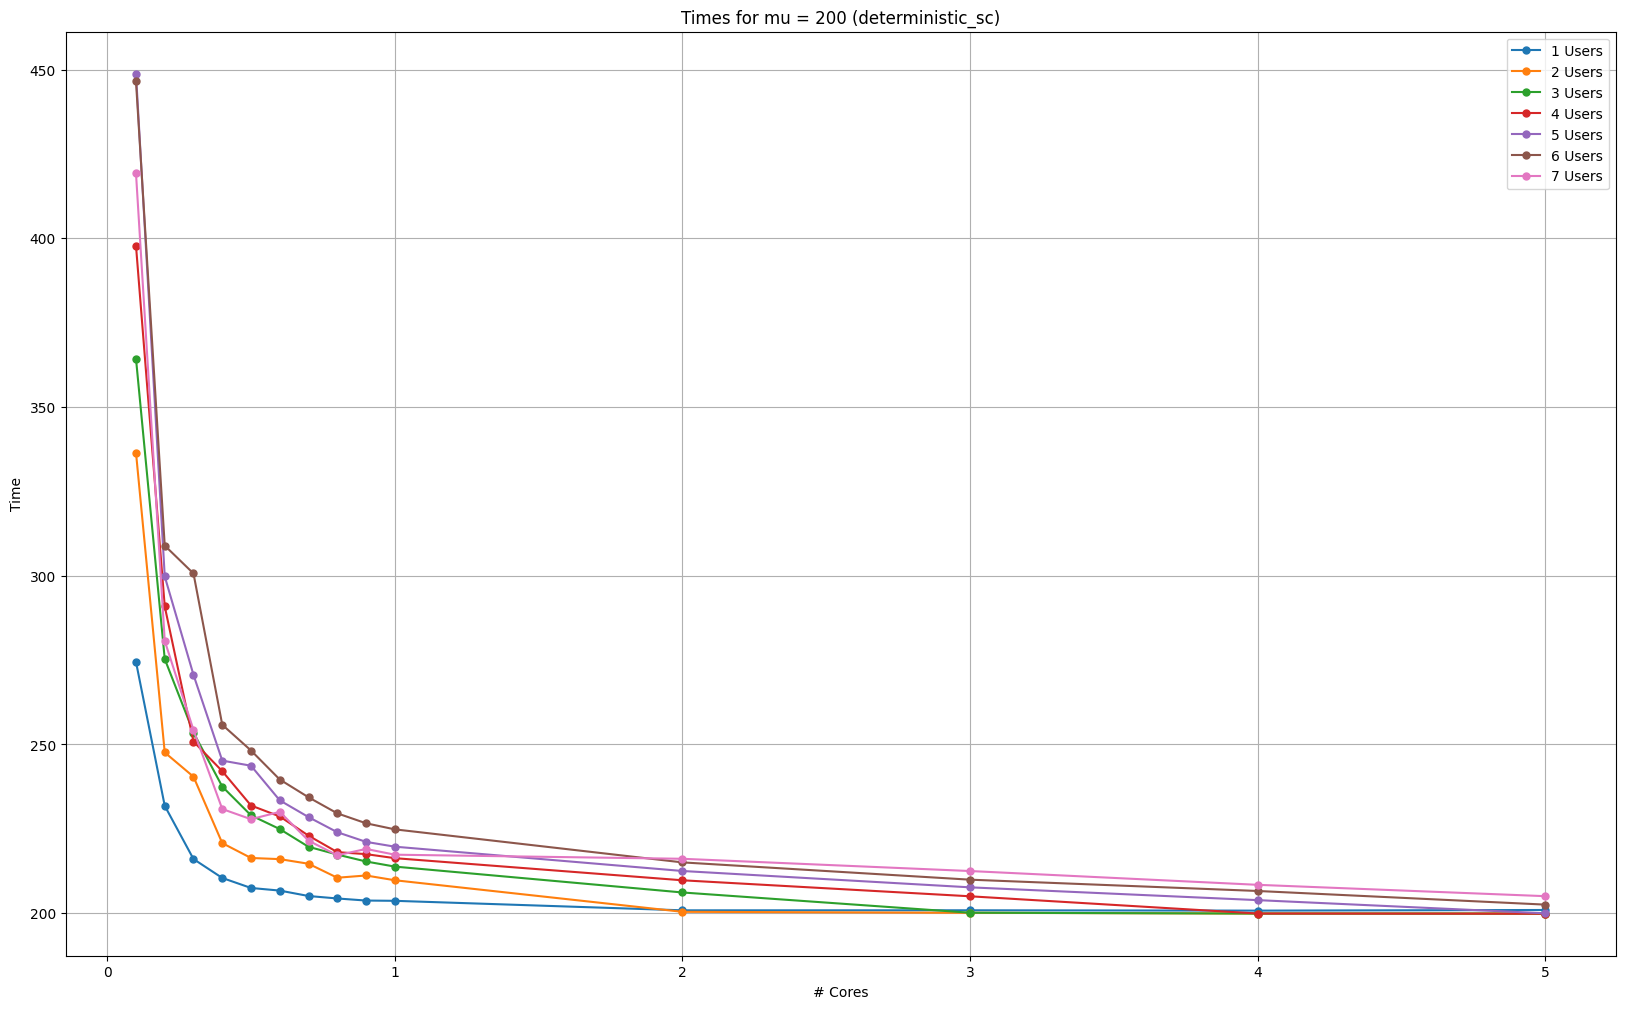

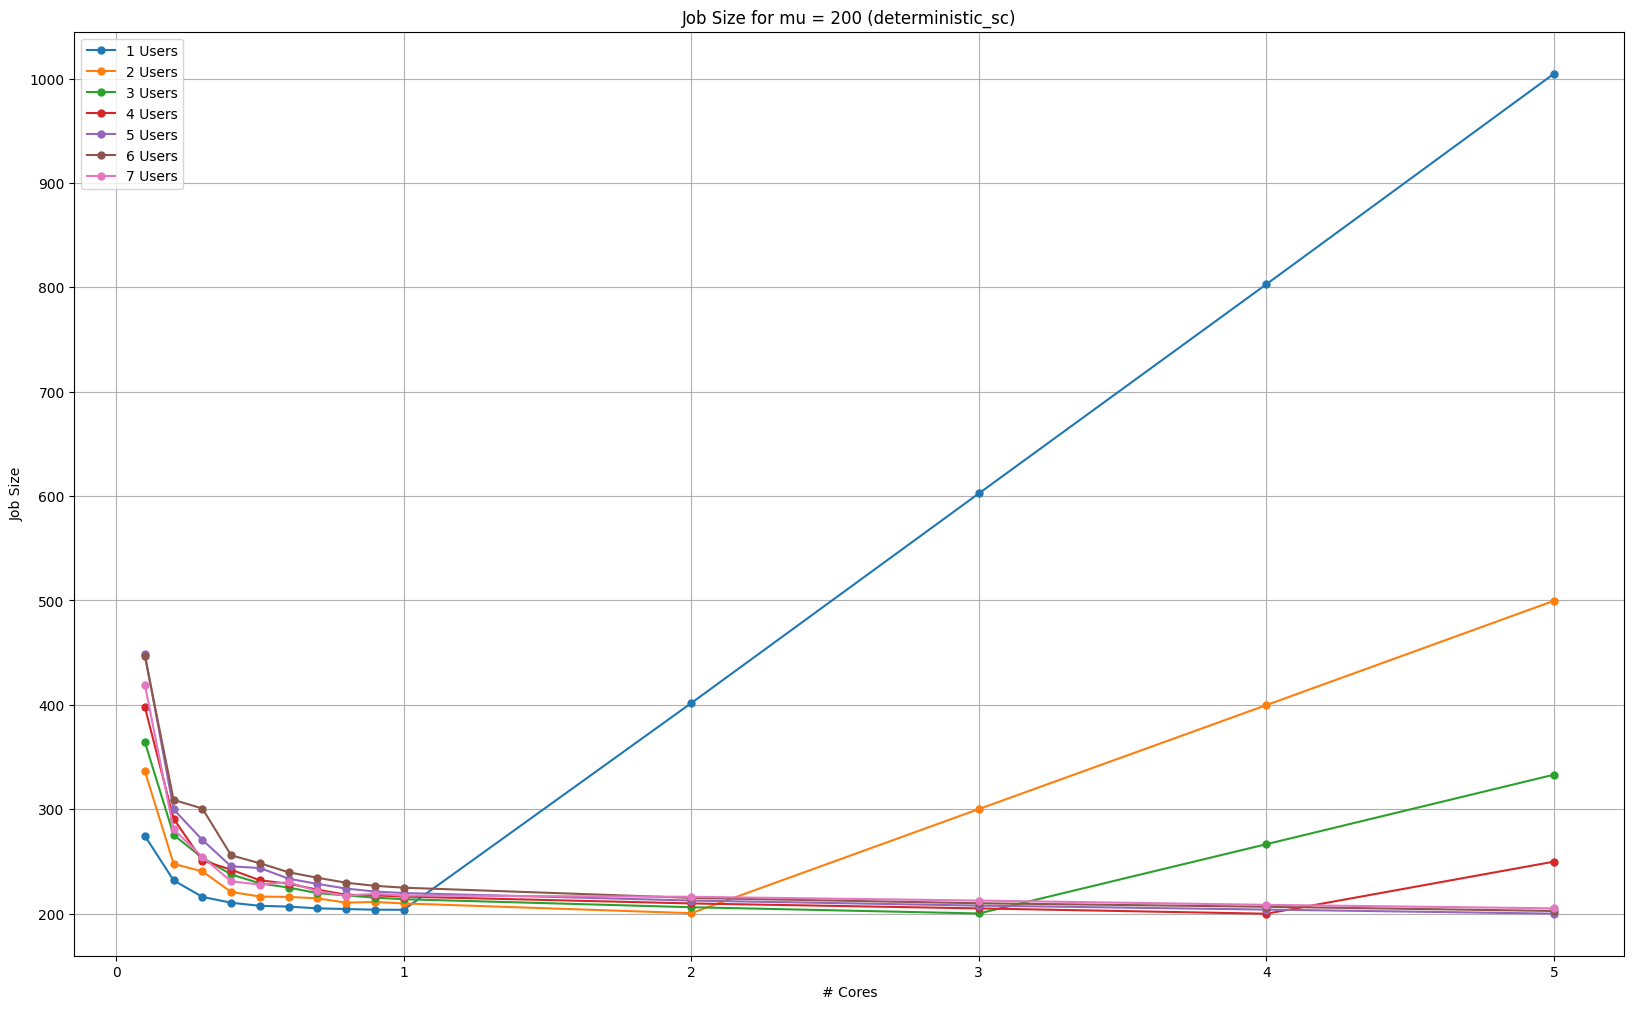

In [5]:
plot_times_and_job_sizes(performance_df)

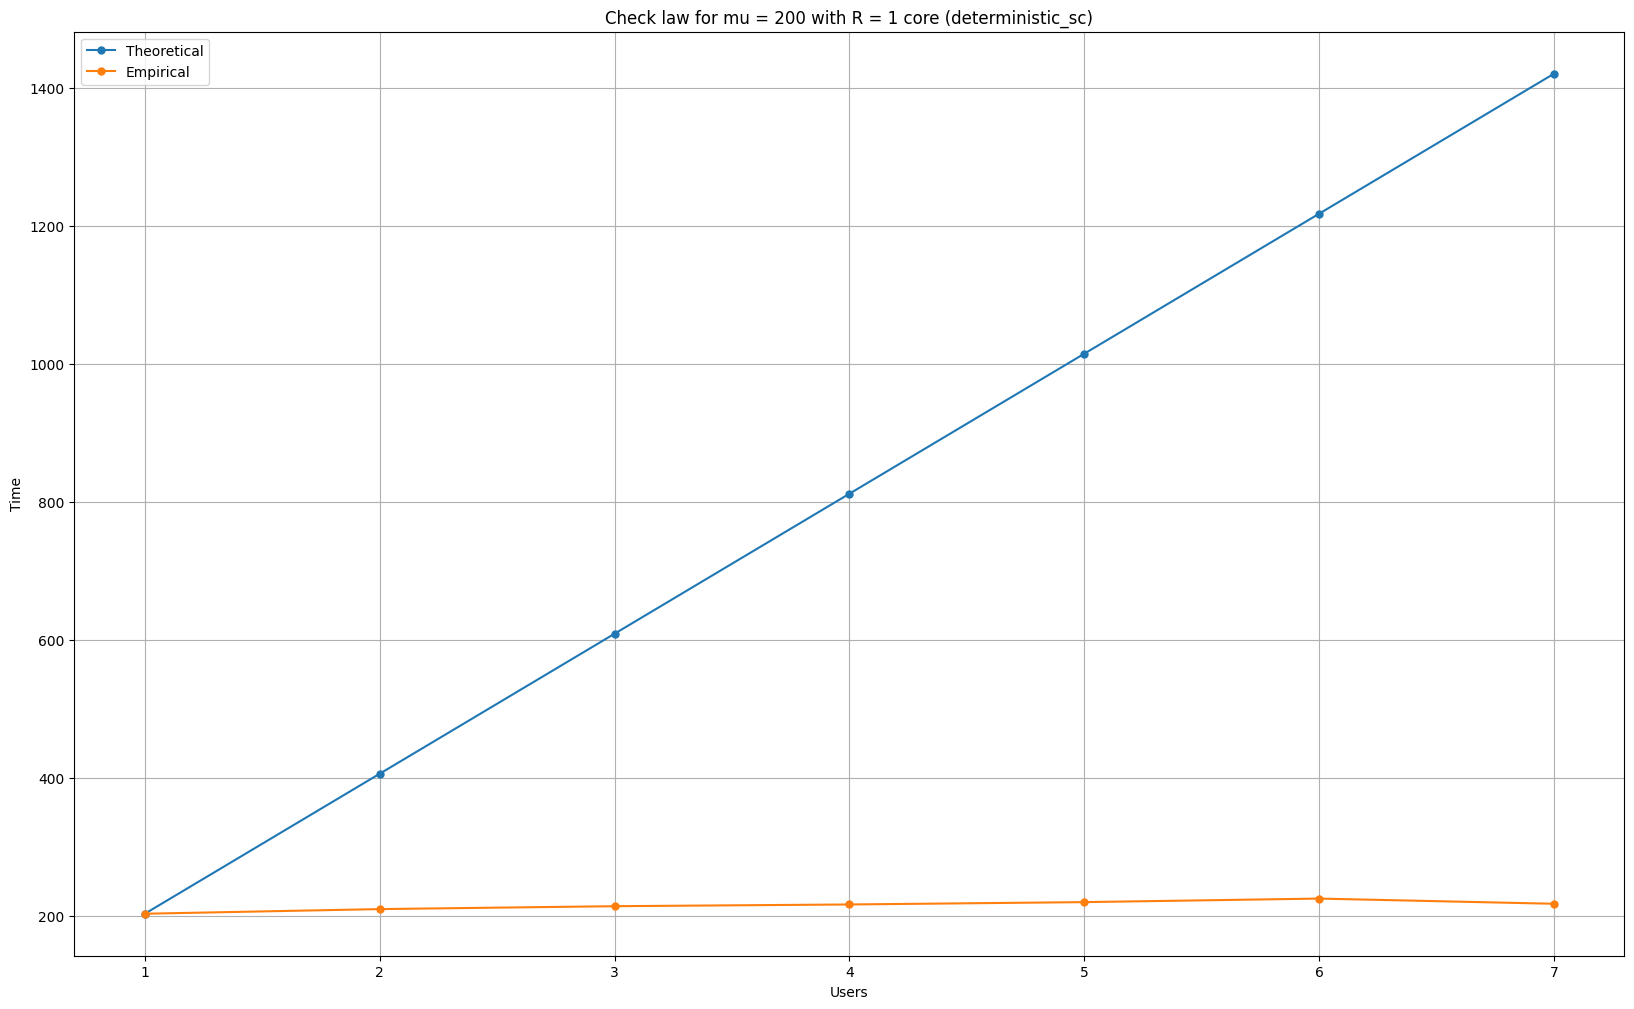

TypeError: 'int' object is not subscriptable

In [6]:
check_law(performance_df, load_df)